# **Routing**

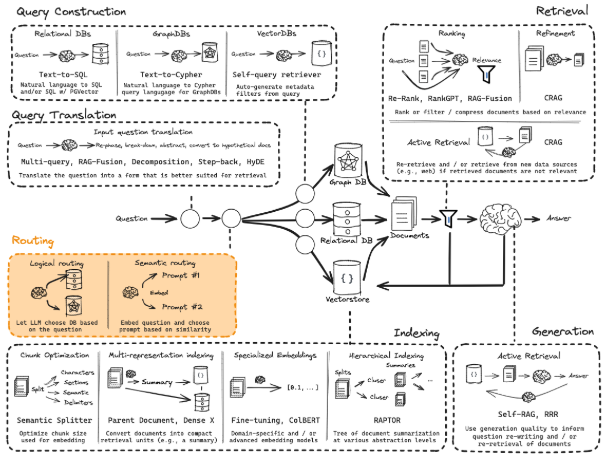

### **Environment**

`(1) Packages`

In [ ]:
%pip install -qU \
langchain \
langchain-core \
langchain-community \
langchain-openai \
langchain-chroma \
langchain-text-splitters \
chromadb \
beautifulsoup4 \
tiktoken \
lxml \
langsmith

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.6/139.6 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.6/561.6 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.1/122.1 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.9/109.9 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.5/676.5 kB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5

`(2) LangSmith`

https://docs.smith.langchain.com/

LangSmith, büyük dil modelleri (LLM) ve LangChain kullanılarak geliştirilen uygulamaları test etmek, değerlendirmek, izlemek (tracing) ve hata ayıklamak için kullanılan bulut tabanlı bir platformdur.

In [ ]:
import os

# "LANGCHAIN" yerine "LANGSMITH" kullanıyoruz ve ENDPOINT ekliyoruz
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGSMITH_API_KEY"] = "your-api-key"
os.environ["LANGSMITH_PROJECT"] = "RAG Routing and Query Construction"

`(3) API Keys`

In [ ]:
os.environ['OPENAI_API_KEY'] = os.environ['OPENAI_API_KEY'] = "your-api-key"

### **Logical routing**

Use function-calling for classification.

Flow:

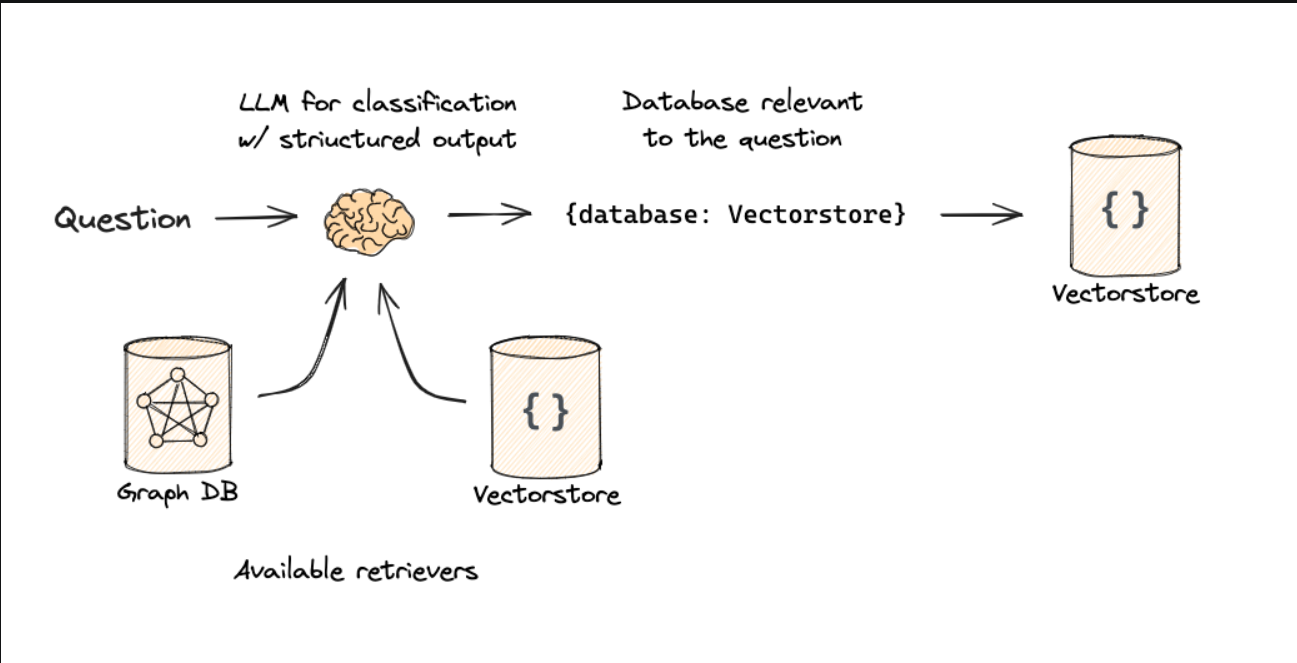

Sistemin doğruluğunu artırmak için kullanılabilecek bu yapı, gelen bir sorgunun içeriğine (intent) göre en doğru veri kaynağına dinamik olarak yönlendirilmesini sağlar.


*   Question (Sorgu): Sisteme kullanıcı tarafından bir soru girilir.

*   Available Retrievers (Mevcut Geri Getiriciler): Alt kısımda sistemin erişebildiği farklı veri tabanı türleri gösteriliyor. Örneğin; düğüm ve ilişki tabanlı veriler için bir Graph DB ve anlamsal (semantic) arama veya gömme (embedding) vektörleri için bir Vectorstore.

*   LLM for classification w/ structured output (Sınıflandırma ve Yapılandırılmış Çıktı için LLM): Gelen soru, doğrudan bir veri tabanında aranmak yerine önce bir dil modeline (LLM) girer. Bu aşamada LLM bir metin üreticisi olarak değil, bir yönlendirici (router) ve sınıflandırıcı olarak çalışır. Model, alt kısımdaki mevcut veri kaynaklarından haberdardır.

*   Yapılandırılmış Çıktı (Structured Output): LLM soruyu analiz eder ve cevabın hangi veri tabanında bulunma ihtimalinin yüksek olduğuna karar verir. Slayttaki örnekte LLM, sorunun bağlamının vektör veri tabanına uygun olduğuna karar verip doğrudan bir kod veya JSON objesi gibi formatlanmış bir çıktı üretir: {database: Vectorstore}. Function calling (fonksiyon çağırma) özellikleri tam olarak bu noktada devreye girer.

*   Hedef Veri Tabanına Yönlendirme (Vectorstore): Sistem, LLM'in ürettiği bu yapılandırılmış çıktıyı okur ve arama (retrieval) işlemini sadece modelin seçtiği spesifik veri tabanı üzerinde gerçekleştirir.


Yukarıdaki görsel, çoklu veri tabanlarına sahip sistemlerde karmaşayı önlemek için LLM'in kendi muhakeme yeteneğini kullanarak arama işlemini doğru kaynağa yönlendirme (routing) stratejisini anlatmaktadır.


Logical Routing'in en önemli püf noktası şudur: Yapay zekaya serbest metin cevabı verdirmek yerine, ondan yapılandırılmış çıktı (Structured Output) istemek.

Yapılandırılmış Çıktı (Structured Output), yapay zekanın size sohbet eder gibi paragraflar dolusu düz metin (Serbest Metin / Free-Text) yazması yerine, bilgisayar programlarının doğrudan okuyup işleyebileceği JSON, Python Nesnesi veya Standart Şablon (Schema) formatında veri üretmesidir.

```
{
  "duygu_durumu": "kizgin",
  "kategori": "kargo_gecikmesi",
  "aciliyet_seviyesi": "kritik",
  "geciken_gun_sayisi": 5,
  "insan_temsilciye_aktarilsin_mi": true
}
```



```
# Yapay zeka çıktısı doğrudan Python objesi haline gelir:
if sonuc.aciliyet_seviyesi == "kritik" and sonuc.insan_temsilciye_aktarilsin_mi:
    insan_temsilcisini_ara()

```




Büyük bir hastaneye girdiğinizi düşünün:

Kapıda bir Danışma Görevlisi (LLM Router) durur.
Şikayetinizi belirtirsiniz: "Gözümde bir kızarıklık ve ağrı var."
Danışma görevlisi bu cümleyi dinler, mantık yürütür ve sizi doğrudan Göz Polikliniği'ne yönlendirir. Sizi Cildiye veya Kulak-Burun-Boğaz bölümüne göndermez.
İşte Logical Routing, yapay zekanın gelen soruyu okuyup tıpki bu danışma görevlisi gibi doğru "bölüme" sevk etmesidir.

In [ ]:
from typing import Literal #Yapay zekanın seçebileceği seçenekleri kesin olarak sınırlandırır.

from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field # Python'da veri tiplerini doğrulamak için kullanılır pydantic.
from langchain_openai import ChatOpenAI

# Data model
class RouteQuery(BaseModel):
    """Route a user query to the most relevant datasource.
    Kullanıcı sorusunu en alakalı veri kaynağına yönlendirir."""

    # Seçenekleri kesin olarak sınırlandırır.
    datasource: Literal["python_docs", "js_docs", "golang_docs"] = Field(
        ...,
        description="Given a user question choose which datasource would be most relevant for answering their question",
        #Yapay zeka modeli bu alandaki açıklamayı okuyarak hangi durumda neyi seçeceğine karar verir.
    )

# LLM with function call
#Yapay zekanın (GPT) standart metin yanıtı vermek yerine, yukarıda tanımladığımız nesneyi JSON formatında döndürmesini sağlıyoruz:
llm = ChatOpenAI(model="gpt-3.5-turbo-0125", temperature=0)

# Bu metod, OpenAI'ın Function Calling (İşlev Çağırma) özelliğini arkada çalıştırır. LLM cevabını doğrudan Pydantic nesnesi olarak döndürür.
structured_llm = llm.with_structured_output(RouteQuery)

# Prompt
#Yapay Zekaya Görevini Anlatan Sistem Komutu (Prompt)
system = """You are an expert at routing a user question to the appropriate data source.

Based on the programming language the question is referring to, route it to the relevant data source."""

prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "{question}"),
    ]
)

# Define router
# Yönlendiriciyi Bağlama (Router Chain)
router = prompt | structured_llm

/usr/local/lib/python3.12/dist-packages/langchain_openai/chat_models/base.py:2480: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo-0125 since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


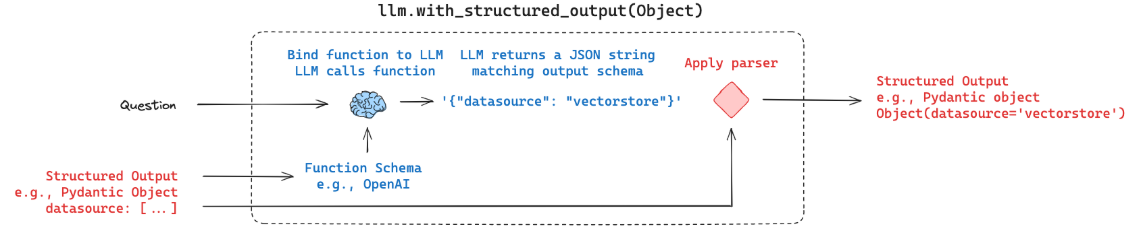

Tanımladığımız Pydantic Python nesnesi, arka planda OpenAI/LLM modellerinin anladığı bir "Function Call (Fonksiyon Çağrısı) Şemasına" dönüştürülür.
Bind function to LLM: Yapay zekaya şu söylenir: "Sana bir soru soruyorum ama bana düz metin yazma, sadece şu fonksiyon şemasına uygun bir çıktı üret!"

LLM returns a JSON string...: Yapay zeka soruyu analiz eder ve şemaya %100 uyan bir ham JSON metni döndürür:
`'{"datasource": "vectorstore"}'`
Apply parser (Kırmızı Dörtgen): LangChain devreye girer. Üretilen bu ham JSON metnini yakalar ve doğrular (validate eder).

Structured Output: Ham JSON metni, doğrudan Python içinde kullanabileceğimiz nesneye (Object) dönüştürülür:
`Object(datasource='vectorstore')`

Yukarıdaki görsel llm.with_structured_output metodunun arka plandaki çalışma mantığını açıklamaktadır.

In [ ]:
question = """Why doesn't the following code work:

from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_messages(["human", "speak in {language}"])
prompt.invoke("french")
"""

result = router.invoke({"question": question})

In [ ]:
result

RouteQuery(datasource='python_docs')

In [ ]:
result.datasource

'python_docs'

 Routing mantıksal kararı verir, Dinamik Dallanma (Dynamic Branching) ise o karara göre kodu fiilen doğru yola sevk eder.

### **Dinamik Dallama**

Dinamik Dallanma (Dynamic Branching), Yapay Zekanın sınıflandırma kararına göre sistemin kod akışını/rotasını anında ve otomatik olarak değiştirmesini sağlar.

Bir RAG sisteminde Yapay Zeka kararını verdikten sonra ("Bu soru bir Python sorusudur"), sistemin durup "Tamam, o zaman şimdi Python için özel hazırladığım RAG boru hattını çalıştırıyorum" deme mekanizmasıdır.

In [ ]:
from langchain_community.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough, RunnableLambda

embeddings = OpenAIEmbeddings()
llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0)

# ========================================================
# 1. GERÇEK CHROMADB VERİTABANLARININ YÜKLENMESİ
# ========================================================

# Python Dokümanlarının Vektör Veritabanı
python_vectorstore = Chroma(persist_directory="./chroma_python", embedding_function=embeddings)
python_retriever = python_vectorstore.as_retriever(search_kwargs={"k": 3})

# JavaScript Dokümanlarının Vektör Veritabanı
js_vectorstore = Chroma(persist_directory="./chroma_js", embedding_function=embeddings)
js_retriever = js_vectorstore.as_retriever(search_kwargs={"k": 3})

# Go Dokümanlarının Vektör Veritabanı
golang_vectorstore = Chroma(persist_directory="./chroma_golang", embedding_function=embeddings)
golang_retriever = golang_vectorstore.as_retriever(search_kwargs={"k": 3})


# ========================================================
# 2. HER BİRİ İÇİN RAG ZİNCİRİ (ChromaDB + Prompt + LLM)
# ========================================================

rag_prompt = ChatPromptTemplate.from_template("""
Aşağıdaki doküman parçalarını kullanarak soruyu yanıtla:

Dokümanlar:
{context}

Soru: {question}
""")

# Python RAG Zinciri (Gidip Python ChromaDB'sinden veri çeker)
python_rag_chain = (
    {"context": python_retriever, "question": RunnablePassthrough()}
    | rag_prompt
    | llm
    | StrOutputParser()
)

# JS RAG Zinciri (Gidip JS ChromaDB'sinden veri çeker)
js_rag_chain = (
    {"context": js_retriever, "question": RunnablePassthrough()}
    | rag_prompt
    | llm
    | StrOutputParser()
)

# Go RAG Zinciri (Gidip Go ChromaDB'sinden veri çeker)
golang_rag_chain = (
    {"context": golang_retriever, "question": RunnablePassthrough()}
    | rag_prompt
    | llm
    | StrOutputParser()
)


# ========================================================
# 3. DİNAMİK DALLANMA (GERÇEK CHROMADB ARAMALARI)
# ========================================================

def route_and_execute(input_data):
    question = input_data["question"]
    datasource = input_data["route"].datasource.lower()

    print(f"\n🔍 Arama Yapılacak Veritabanı: {datasource.upper()}")

    if "python" in datasource:
        # FİİLEN PYTHON CHROMADB'DE ARAMA YAPAR VE CEVAPLAR
        return python_rag_chain.invoke(question)

    elif "js" in datasource:
        # FİİLEN JS CHROMADB'DE ARAMA YAPAR VE CEVAPLAR
        return js_rag_chain.invoke(question)

    elif "golang" in datasource:
        # FİİLEN GO CHROMADB'DE ARAMA YAPAR VE CEVAPLAR
        return golang_rag_chain.invoke(question)


# ========================================================
# 4. TAM SİSTEMİ ÇALIŞTIRMA
# ========================================================

full_chain = (
    {
        "question": RunnablePassthrough(),
        "route": router  # Önceden yaptığımız Router (Yönlendirici)
    }
    | RunnableLambda(route_and_execute)
)



/tmp/ipykernel_861/293503999.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import Chroma
/tmp/ipykernel_861/293503999.py:15: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  python_vectorstore = Chroma(persist_directory="./chroma_python", embedding_function=embeddings)


In [ ]:
# ÖRNEK SORGULAMA:
# Kullanıcı: "Python'da listeleri nasıl sıralarım?"
# 1. Router karar verir -> datasource = 'python_docs'
# 2. Dallanma fonksiyonu -> Sadece ./chroma_python veritabanında arama yapar!
# 3. JS ve Go veritabanlarına HİÇ DOKUNULMAZ.

soru = "Python'da listeleri nasıl sıralarım?"

# Otomatik olarak Router çalışır, kararı alır ve ilgili dallanmayı tetikler:
sonuc = full_chain.invoke(soru)

print(sonuc)



🔍 Arama Yapılacak Veritabanı: PYTHON_DOCS
Python'da listeleri sıralamak için `sort()` fonksiyonunu kullanabilirsiniz. Bu fonksiyon, listedeki elemanları küçükten büyüğe veya büyükten küçüğe doğru sıralamanıza olanak tanır. Örneğin, aşağıdaki gibi bir liste oluşturduğunuzu varsayalım:

```python
numbers = [3, 1, 4, 1, 5, 9, 2, 6, 5, 3, 5]
```

Bu listedeki elemanları küçükten büyüğe sıralamak için şu şekilde bir kod yazabilirsiniz:

```python
numbers.sort()
print(numbers)
```

Bu kodu çalıştırdığınızda, listenin sıralanmış halini ekrana yazdıracaktır. Eğer listedeki elemanları büyükten küçüğe sıralamak isterseniz, `sort()` fonksiyonunun `reverse` parametresini `True` olarak ayarlayabilirsiniz:

```python
numbers.sort(reverse=True)
print(numbers)
```

Bu şekilde, listedeki elemanlar büyükten küçüğe doğru sıralanacaktır.


### **Semantic Routing**

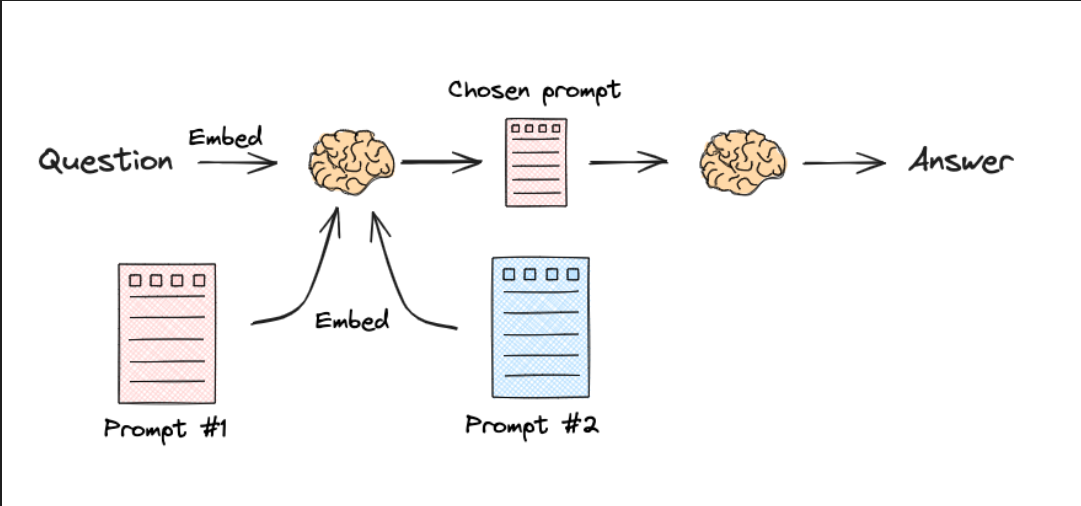

Logical Routing de "Bu soru hangi kategoriye ait?" diye soruyorduk. Bu yöntem mantıklıydı ama yavaştı ve token maliyeti vardı.

Semantic Routing ise yönlendirme kararı verirken BÜYÜK DİL MODELİ ÇALIŞTIRMAZ (LLM Çağrısı Yapmaz).

bunun yerine soruyu Sayısal Vektörlere (Embeddings) dönüştürür ve önceden hazırladığımız kategorilerle Matematiksel Benzerliğini (Cosine Similarity) hesaplar. Hangisine anlamsal olarak en yakınsa, soruyu ışık hızında (milisaniyeler içinde) o yola fırlatır!

Elinizde yan yana duran iki güçlü mıknatıs olduğunu düşünün:

1. Mıknatıs (Fizik Kutusu): İçinde kuantum, yerçekimi, kara delik, kütle, kuvvet gibi kelimelerin temsil ettiği bir anlamsal çekim alanı var.
2. Mıknatıs (Matematik Kutusu): İçinde türev, integral, denklem, matris, olasılık anlamsal çekim alanı var.
Kullanıcı gelip soruyor: "Kara delik nedir?"

Soru anında bir bilyeye (Vektöre) dönüştürülür ve iki mıknatısın arasına bırakılır. Soru anlamsal olarak Fizik Mıknatısına çok daha yakın olduğu için şak diye Fizik kutusuna yapışır!

Yapay zekanın "düşünmesine" gerek kalmadan, matematiksel çekim gücüyle doğru yola girmiş olur.

Görsele bakılınca

Prompt #1 & Prompt #2: Elimizde önceden tanımlanmış farklı istem şablonları var (Örn: Fizik Profesörü İle Cevapla ve Matematikçi İle Cevapla).

Embed Okları: Hem kullanıcının sorduğu Question (Soru), hem de elimizdeki bu istem şablonları sayısal vektörlere (Embeddings) dönüştürülür.

Buradaki birinci beyin ikonu, bir LLM (GPT-3.5) değildir! Bu adım tamamen Vektör Benzerliği (Cosine Similarity) hesabıdır:

Kullanıcı sorusunun vektörü ile Prompt #1 ve Prompt #2 vektörleri karşılaştırılır.
Hangi şablon anlamsal olarak soruya en yakınsa o kazanır.

İstem Seçimi (Chosen Prompt)
Vektör benzerlik testini kazanan şablon Chosen prompt (Seçilen Şablon) olarak belirlenir (Örn: Fizik Şablonu).

Cevap Üretimi (Sağ Taraf)
Chosen prompt + Kullanıcı Soru: Seçilen şablon ve kullanıcının sorusu birleştirilir.

İkinci Beyin İkonu: İşte buradaki ikinci beyin, gerçek Yapay Zeka Modelidir (LLM).

Answer (Cevap): Yapay Zeka modeline seçilen uzman rolü giydirilerek nihai cevap kullanıcıya üretilir.

In [ ]:
from langchain.utils.math import cosine_similarity
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

# Two prompts
# Önce yönlendirmek istediğimiz yolları/uzmanlıkları tanımlıyoruz:
physics_template = """You are a very smart physics professor. \
You are great at answering questions about physics in a concise and easy to understand manner. \
When you don't know the answer to a question you admit that you don't know.

Here is a question:
{query}"""

math_template = """You are a very good mathematician. You are great at answering math questions. \
You are so good because you are able to break down hard problems into their component parts, \
answer the component parts, and then put them together to answer the broader question.

Here is a question:
{query}"""


# Embed prompts
embeddings = OpenAIEmbeddings()
prompt_templates = [physics_template, math_template]
#Bu şablonlar metindir. Matematiksel olarak karşılaştırabilmek için onları OpenAIEmbeddings() kullanarak sayı dizilerine (vektörlere) çeviririz:
prompt_embeddings = embeddings.embed_documents(prompt_templates)

# Route question to prompt
# Kullanıcı soru sorduğunda çalışan yönlendirici fonksiyonumuz:
def prompt_router(input):
    # Embed question
    # 1. Kullanıcı sorusunu da sayısal vektöre çevir
    query_embedding = embeddings.embed_query(input["query"])
    # Compute similarity
    # 2. Sorunun vektörü ile Şablonların vektörleri arasındaki açıyı/benzerliği hesapla
    similarity = cosine_similarity([query_embedding], prompt_embeddings)[0]
    # 3. Benzerlik skoru en yüksek olan şablonu seç!
    most_similar = prompt_templates[similarity.argmax()]
    # Chosen prompt
    print("Using MATH" if most_similar == math_template else "Using PHYSICS")
    return PromptTemplate.from_template(most_similar)


chain = (
    {"query": RunnablePassthrough()}
    | RunnableLambda(prompt_router)
    | ChatOpenAI()
    | StrOutputParser()
)

print(chain.invoke("What's a black hole"))

Süreç Nasıl İşler? Kullanıcı "What's a black hole" (Kara delik nedir?) dediğinde:

"What's a black hole" vektöre dönüşür.
Cosine Similarity (Kosinüs Benzerliği) hesaplanır:
Physics Template ile Benzerlik: %87
Math Template ile Benzerlik: %35
Skor %87 olan PHYSICS seçilir ve soru Fizik Profesörü LLM'ine gönderilir!

# **Query Construction (Sorgu İnşası ve Metadata Filtreleme)**

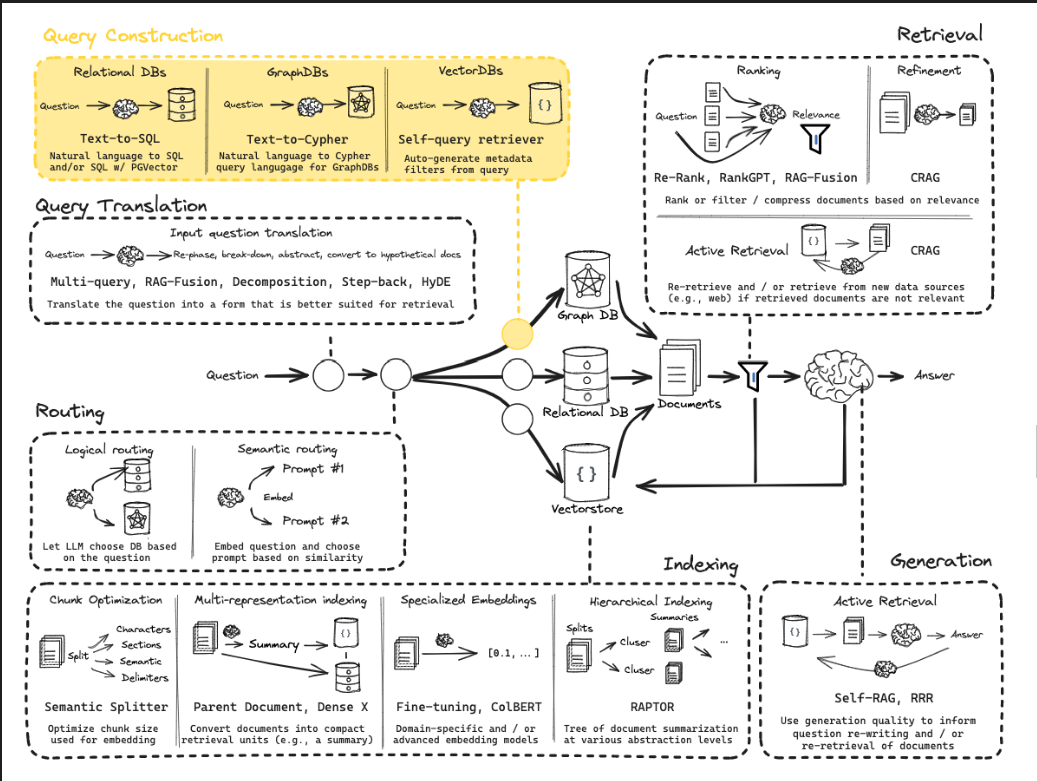

Geleneksel vektör veritabanları metinlerin sadece anlamsal benzerliğine bakar. Ancak gerçek hayatta kullanıcılar aramalarını yaparken sadece konu söylemezler, tarih, sayı, kısıtlama ve filtre de belirtirler.

Örneğin kullanıcı bu soruyu sordu

"2023 yılında yayınlanan ve 5 dakikadan kısa olan LangChain videolarını getir."

Eğer bu cümleyi doğrudan standart bir Vektör Veritabanına (Vectorstore) atarsan, veritabanı "2023" ve "5 dakika" kelimelerini anlamsal bir metin sanıp arar. 2021 yılında çekilmiş 20 dakikalık bir videonun içinde "2023" kelimesi geçiyorsa o videoyu sana getirebilir! Çünkü standart vektör araması matematiksel tarih ve sayısal filtreleme yapamaz. Çözümü ise sorgu yapılandırmadır.

Kullanıcının doğal dilde yazdığı cümleyi alıp, bir Yapay Zeka Sorgu Analizcisine (Query Analyzer) veriyoruz.

Yapay zeka cümleyi ikiye böler:

Arama Metni (Semantic Query): "LangChain videoları" (Vektör veritabanında aranacak konu)
Metadata Filtresi (Structured Filter): Tarih = 2023 VE Süre < 300 saniye (Veritabanına uygulanacak filtre)
İşte bu sürece Query Construction denir.

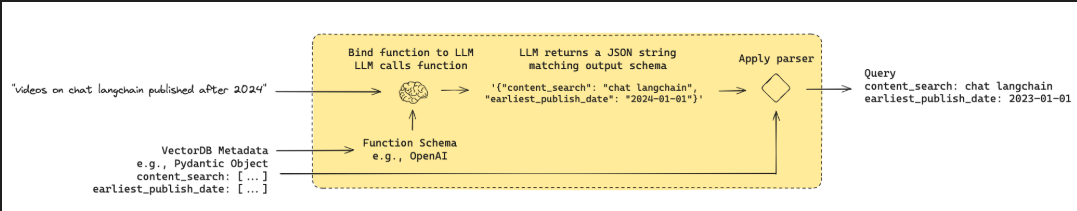

Kullanıcı Sorusu (Doğal Dil):
"Videos on chat langchain published after 2024" (2024'ten sonra yayınlanan chat langchain videoları)

VectorDB Metadata Şeması (Pydantic Nesnesi):
Veritabanımızda neleri filtreleyebileceğimizi belirten veri modeli (content_search, earliest_publish_date vb.).


Bind function to LLM (Beyin İkonu):
Tanımladığımız Pydantic metadata şeması OpenAI'ın Fonksiyon Çağrısı (Function Call) biçimine dönüştürülür ve LLM'e bağlanır.


LLM returns a JSON string... (Orta Kısım):
Yapay Zeka sorudaki cümleyi ayrıştırır:
Konu kısmını: "content_search": "chat langchain"
"published after 2024" kısmını mantıksal tarihe çevirerek: "earliest_publish_date": "2024-01-01" şeklinde bir JSON metni üretir.

Apply parser (Eşkenar Dörtgen İkonu):
LangChain bu JSON metnini yakalar ve Python içinde doğrudan kullanılabilecek nesneye dönüştürür.

Çıktı (Sağ Taraf - Query)
Sistemden çıkan nihai yapılandırılmış sorgu nesnesi:

content_search: chat langchain ➔ Vektör Veritabanında Aranacak Metin
earliest_publish_date: 2024-01-01 ➔ Veritabanına Uygulanacak Tarih Filtresi


In [ ]:
import datetime
from typing import Optional
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.documents import Document

# ========================================================
# ADIM 1: VERİTABANI İÇİN ÖRNEK METADATA VERİ SETİ
# (zengin metadata içeren dokümanlar)
# ========================================================
docs = [
    Document(
        page_content="RAG architectures, vectorstores and retrieval techniques.",
        metadata={
            "title": "Chat LangChain Tutorial",
            "view_count": 50000,
            "publish_date": datetime.date(2023, 5, 10),
            "length_sec": 240  # 4 dakika
        }
    ),
    Document(
        page_content="Building autonomous agents with multi-modal LLM models.",
        metadata={
            "title": "Multi-Modal Agents Guide",
            "view_count": 12000,
            "publish_date": datetime.date(2024, 1, 15),
            "length_sec": 600  # 10 dakika
        }
    )
]

print("✅ Örnek Metadata Yüklendi:", docs[0].metadata)


# ========================================================
# ADIM 2: SORGU ŞEMASINI TANIMLAMA (PYDANTIC MODEL)
# ========================================================
class TutorialSearch(BaseModel):
    """Eğitim videoları veritabanında arama yapmak için sorgu yapısı."""

    content_search: str = Field(
        ...,
        description="Video transkriptlerinde aranacak anlamsal sorgu.",
    )
    title_search: Optional[str] = Field(
        None,
        description="Video başlıklarına uygulanacak sorgu versiyonu.",
    )
    min_view_count: Optional[int] = Field(
        None, description="Minimum izlenme sayısı."
    )
    earliest_publish_date: Optional[datetime.date] = Field(
        None, description="En erken yayınlanma tarihi (YYYY-AA-GG)."
    )
    latest_publish_date: Optional[datetime.date] = Field(
        None, description="En geç yayınlanma tarihi (YYYY-AA-GG)."
    )
    max_length_sec: Optional[int] = Field(
        None, description="Saniye cinsinden maksimum video süresi."
    )

    def pretty_print(self) -> None:
        """Çıktıyı süslü yazdıran yardımcı fonksiyon."""
        for field in self.__fields__:
            val = getattr(self, field)
            if val is not None:
                print(f"  🔹 {field}: {val}")


# ========================================================
# ADIM 3: QUERY ANALYZER (SORGU ANALİZCİSİ) OLUŞTURMA
# ========================================================
system = """You are an expert at converting user questions into database queries.
You have access to a database of tutorial videos about a software library.
Given a question, return a database query optimized to retrieve the most relevant results.

If there are acronyms or words you are not familiar with, do not try to rephrase them."""

prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "{question}"),
    ]
)

llm = ChatOpenAI(model="gpt-3.5-turbo-0125", temperature=0)
structured_llm = llm.with_structured_output(TutorialSearch)

# Ana Sorgu Analizcisi Zinciri
query_analyzer = prompt | structured_llm


# ========================================================
# ADIM 4: DOĞAL DİL İLE SORGU YAPIŞTIRMA VE TEST ETME
# ========================================================

print("\n--- TEST 1: Tarih Filtresi ---")
sorgu1 = query_analyzer.invoke({"question": "videos on chat langchain published in 2023"})
sorgu1.pretty_print()

print("\n--- TEST 2: Süre Kısıtlaması (5 dakikadan kısa) ---")
sorgu2 = query_analyzer.invoke({"question": "how to use multi-modal models in an agent, only videos under 5 minutes"})
sorgu2.pretty_print()


✅ Örnek Metadata Yüklendi: {'title': 'Chat LangChain Tutorial', 'view_count': 50000, 'publish_date': datetime.date(2023, 5, 10), 'length_sec': 240}

--- TEST 1: Tarih Filtresi ---


/usr/local/lib/python3.12/dist-packages/langchain_openai/chat_models/base.py:2480: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo-0125 since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(
/tmp/ipykernel_861/1408012683.py:65: PydanticDeprecatedSince20: The `__fields__` attribute is deprecated, use the `model_fields` class property instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  for field in self.__fields__:


  🔹 content_search: chat langchain
  🔹 earliest_publish_date: 2023-01-01
  🔹 latest_publish_date: 2023-12-31

--- TEST 2: Süre Kısıtlaması (5 dakikadan kısa) ---
  🔹 content_search: multi-modal models in an agent
  🔹 max_length_sec: 300


/tmp/ipykernel_861/1408012683.py:65: PydanticDeprecatedSince20: The `__fields__` attribute is deprecated, use the `model_fields` class property instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  for field in self.__fields__:


In [ ]:
query_analyzer.invoke({"question": "rag from scratch"}).pretty_print()

  🔹 content_search: rag from scratch


/tmp/ipykernel_861/1408012683.py:65: PydanticDeprecatedSince20: The `__fields__` attribute is deprecated, use the `model_fields` class property instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  for field in self.__fields__:


In [ ]:
query_analyzer.invoke(
    {"question": "videos on chat langchain published in 2023"}
).pretty_print()

  🔹 content_search: chat langchain
  🔹 earliest_publish_date: 2023-01-01
  🔹 latest_publish_date: 2023-12-31


/tmp/ipykernel_861/1408012683.py:65: PydanticDeprecatedSince20: The `__fields__` attribute is deprecated, use the `model_fields` class property instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  for field in self.__fields__:


In [ ]:
query_analyzer.invoke(
    {"question": "videos that are focused on the topic of chat langchain that are published before 2024"}
).pretty_print()

  🔹 content_search: chat langchain
  🔹 earliest_publish_date: 2024-01-01


/tmp/ipykernel_861/1408012683.py:65: PydanticDeprecatedSince20: The `__fields__` attribute is deprecated, use the `model_fields` class property instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  for field in self.__fields__:


In [ ]:
query_analyzer.invoke(
    {
        "question": "how to use multi-modal models in an agent, only videos under 5 minutes"
    }
).pretty_print()

  🔹 content_search: multi-modal models in an agent
  🔹 max_length_sec: 300


/tmp/ipykernel_861/1408012683.py:65: PydanticDeprecatedSince20: The `__fields__` attribute is deprecated, use the `model_fields` class property instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  for field in self.__fields__:
